In [2]:
import pandas as pd
import os

years = list(range(2015, 2022))
# races = ['white', 'black', 'indian', 'asian', 'hawaii', 'other', 'multi']

# Initialize an empty DataFrame to store the final results
final_risk_prevalence_all_years = pd.DataFrame()

# Loop through each year and process the files
for year in years:
    file_path = f'../health_after_prediction/MH_CB_prediction_{year}.csv'
    df = pd.read_csv(file_path)
    final_risk_prevalence = pd.DataFrame()
    df['weighted_risk'] = df['Population'] * df['predicted_risk']

    final_risk_prevalence = df.groupby('GEO_ID').agg({'weighted_risk': 'sum', 'Population': 'sum'}).reset_index()
    final_risk_prevalence['MH_prevalence'] = final_risk_prevalence['weighted_risk'] / final_risk_prevalence['Population']
    
    output_file_path = f'../Mental Health Prevalence/GEOID_MHprevalence_{year}_CBlevel.csv'
    final_risk_prevalence.to_csv(output_file_path, index=False)
    

In [4]:
final_risk_prevalence

,GEO_ID,weighted_risk,Population,MH_prevalence
0,1000000US060014001001007,12.197364,95,0.128393
1,1000000US060014001001008,2.104339,20,0.105217
2,1000000US060014001001011,1.151171,12,0.095931
3,1000000US060014001001013,0.085807,1,0.085807
4,1000000US060014001001014,2.093885,18,0.116327
...,...,...,...,...
13229,1000000US060019832001050,3.518653,18,0.195481
13230,1000000US060019832001052,4.619751,33,0.139992
13231,1000000US060019832001053,10.634405,60,0.177240
13232,1000000US060019832001054,27.837926,167,0.166694


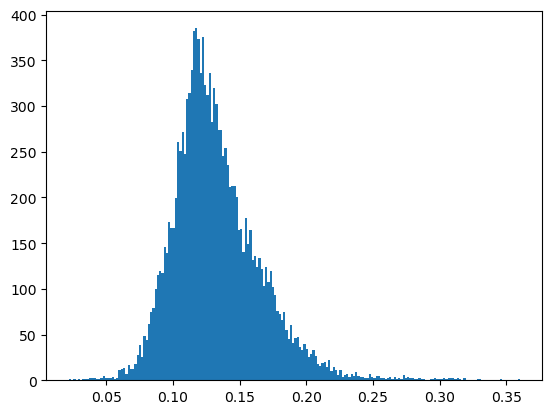

In [15]:
# 输出蒙特卡洛后数据分布
import matplotlib.pyplot as plt
plt.show()
plt.hist(final_risk_prevalence['MH_prevalence'], bins = 200)
plt.show()